# Sugar Crystal Quality Inspection

## Modules

In [128]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

## Decision Graph

### Domain Knowledge

In [130]:
STATE_TEMPLATES = {
    "unsaturated": {
        "supersaturation_ratio": (0.95, 1.00),
        "nucleation_risk": "none",
        "growth_stability": "none"
    },
    "metastable": {
        "supersaturation_ratio": (1.05, 1.25),
        "nucleation_risk": "low",
        "growth_stability": "stable"
    },
    "intermediate": {
        "supersaturation_ratio": (1.20, 1.35),
        "nucleation_risk": "medium",
        "growth_stability": "transition"
    },
    "labile": {
        "supersaturation_ratio": (1.30, 1.50),
        "nucleation_risk": "high",
        "growth_stability": "unstable"
    }
}

### Confidence-Weighted Inference

In [ ]:
def infer_supersaturation_range(crystal_state, confidence):
    low, high = STATE_TEMPLATES[crystal_state]["supersaturation_ratio"]
    center = (low + high) / 2
    width = (high - low) * (1 - confidence)
    return (center - width / 2, center + width / 2)

### Construction of Inferred State

In [ ]:
def build_inferred_state(vit_output):
    cs = vit_output["crystal_state"]
    conf = vit_output["confidence"]

    inferred = {
        "crystal_state": cs,
        "confidence": conf,
        "supersaturation_ratio_range": infer_supersaturation_range(cs, conf),
        "nucleation_risk": STATE_TEMPLATES[cs]["nucleation_risk"],
        "growth_stability": STATE_TEMPLATES[cs]["growth_stability"]
    }

    return inferred

### Graph

In [95]:
CDG = nx.DiGraph()

 ### Nodes

In [96]:
nodes = {
    "observed": ["crystal_state"],
    "derived": [
        "supersaturation_ratio_range",
        "nucleation_risk",
        "growth_stability"
    ],
    "action": [
        "reduce_seeding",
        "emergency_dilution",
        "hold_process",
        "increase_evaporation"
    ]
}

for layer, ns in nodes.items():
    for n in ns:
        CDG.add_node(n, layer=layer)

### Edges

In [97]:
CDG.add_edge("crystal_state", "supersaturation_ratio_range")
CDG.add_edge("crystal_state", "nucleation_risk")
CDG.add_edge("crystal_state", "growth_stability")

CDG.add_edge("nucleation_risk", "reduce_seeding")
CDG.add_edge("nucleation_risk", "emergency_dilution")
CDG.add_edge("growth_stability", "hold_process")
CDG.add_edge("growth_stability", "increase_evaporation")


### Endpoint Decisions

In [ ]:
def decide_actions(derived_state):
    actions = []

    if derived_state["nucleation_risk"] == "high":
        actions.append("reduce_seeding")
        actions.append("emergency_dilution")

    if derived_state["growth_stability"] == "stable":
        actions.append("hold_process")
    else:
        actions.append("increase_evaporation")

    return actions

### Visualization

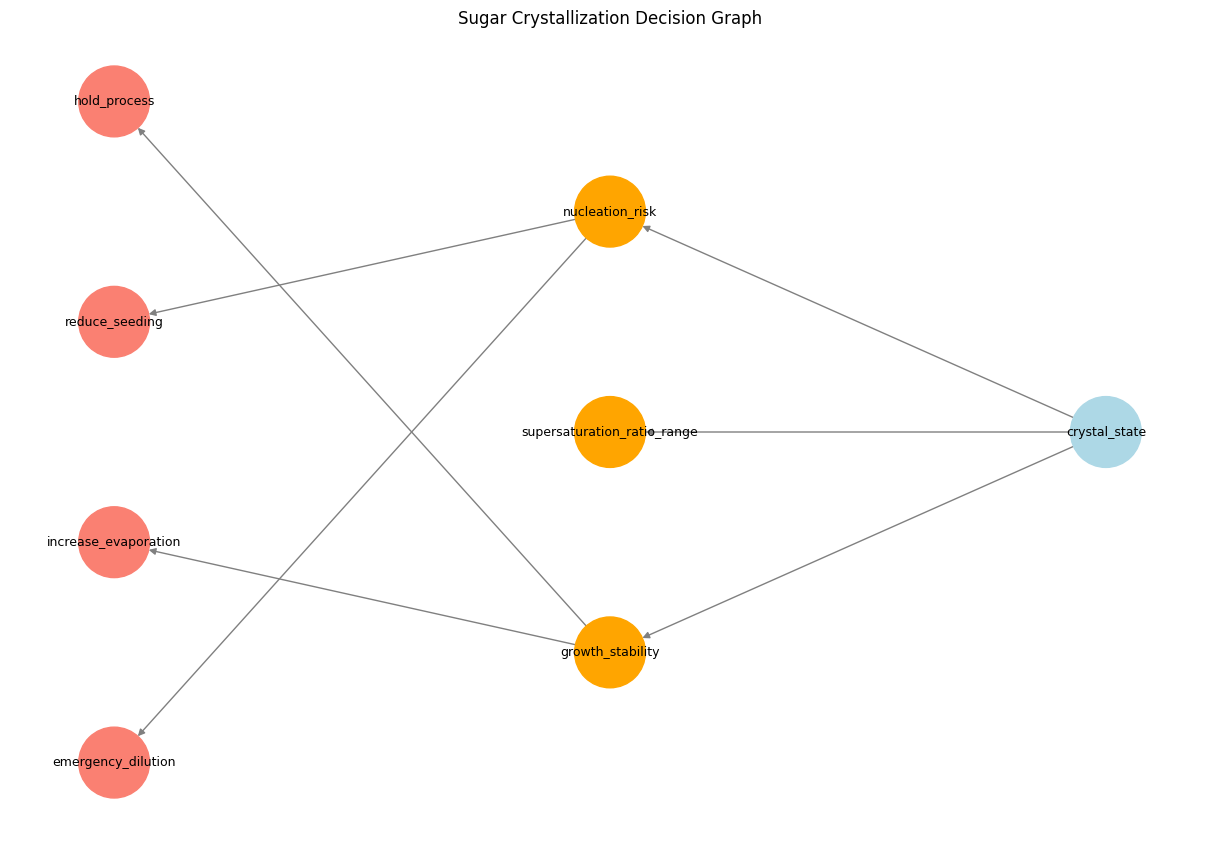

In [99]:
pos = nx.multipartite_layout(CDG, subset_key="layer")

color_map = []
for n in CDG.nodes():
    layer = CDG.nodes[n]["layer"]
    if layer == "observed":
        color_map.append("lightblue")
    elif layer == "derived":
        color_map.append("orange")
    else:
        color_map.append("salmon")

plt.figure(figsize=(12, 8))
nx.draw(
    CDG,
    pos,
    with_labels=True,
    node_color=color_map,
    node_size=2600,
    font_size=9,
    edge_color="gray"
)
plt.title("Sugar Crystallization Decision Graph")
plt.show()

### Sample Run - Without ViT

In [100]:
vit_output = {
    "crystal_state": "labile",
    "confidence": 0.87
}

In [ ]:
kg_input_state = build_inferred_state(vit_output)
kg_input_state

{'crystal_state': 'labile',
 'confidence': 0.87,
 'supersaturation_ratio_range': (1.387, 1.4129999999999998),
 'nucleation_risk': 'high',
 'growth_stability': 'unstable'}

In [ ]:
final_actions = decide_actions(kg_input_state)
final_actions

['reduce_seeding', 'emergency_dilution', 'increase_evaporation']

## State Transition Graph

In [ ]:
# crystallization_state_graph
CSG = nx.DiGraph()

### Nodes

In [ ]:
CSG.add_node(
    "UNSATURATED",
    sigma_range=(0.95, 1.00),
    nucleation="none",
    growth="none",
    visual="clear_liquid"
)

CSG.add_node(
    "METASTABLE",
    sigma_range=(1.05, 1.25),
    nucleation="low",
    growth="controlled",
    visual="clear_with_crystals"
)

CSG.add_node(
    "INTERMEDIATE",
    sigma_range=(1.20, 1.35),
    nucleation="medium",
    growth="mixed",
    visual="cloudy"
)

CSG.add_node(
    "LABILE",
    sigma_range=(1.30, 1.50),
    nucleation="high",
    growth="uncontrolled",
    visual="opaque_fines"
)

### Edges

In [ ]:
CSG.add_edge(
    "UNSATURATED",
    "METASTABLE",
    trigger="supersaturation_increase",
    risk="low",
    controllability="high"
)

CSG.add_edge(
    "METASTABLE",
    "INTERMEDIATE",
    trigger="excess_evaporation",
    risk="medium",
    controllability="medium"
)

CSG.add_edge(
    "INTERMEDIATE",
    "LABILE",
    trigger="runaway_supersaturation",
    risk="high",
    controllability="low"
)

CSG.add_edge(
    "LABILE",
    "INTERMEDIATE",
    trigger="dilution_or_cooling",
    risk="medium",
    controllability="medium"
)

CSG.add_edge(
    "INTERMEDIATE",
    "METASTABLE",
    trigger="stabilized_growth",
    risk="low",
    controllability="high"
)

### Transitions

In [ ]:
def score_transitions(graph, active_state):
    scores = {}

    for _, dst, data in graph.out_edges(active_state, data=True):
        risk_weight = {"low": 0.2, "medium": 0.5, "high": 0.8}[data["risk"]]
        controllability = {"high": 0.9, "medium": 0.6, "low": 0.3}[data["controllability"]]

        scores[dst] = risk_weight * (1 - controllability)

    return scores

### Visualization

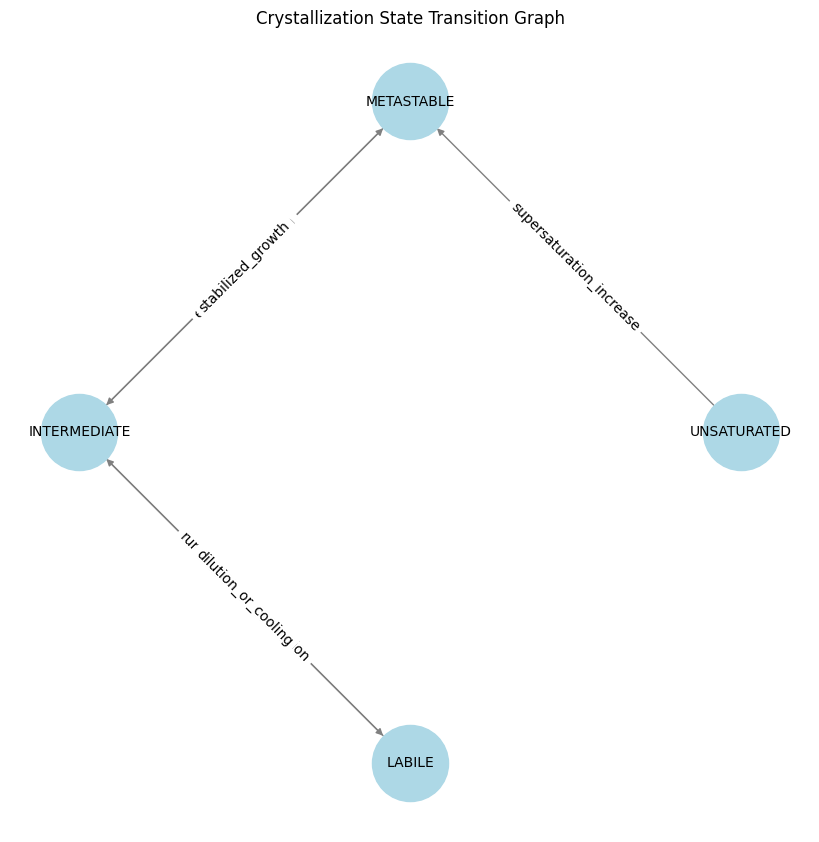

In [ ]:
pos = nx.circular_layout(CSG)

plt.figure(figsize=(8, 8))
nx.draw(
    CSG,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=10,
    edge_color="gray"
)

edge_labels = {
    (u, v): d["trigger"]
    for u, v, d in CSG.edges(data=True)
}

nx.draw_networkx_edge_labels(CSG, pos, edge_labels=edge_labels)

plt.title("Crystallization State Transition Graph")
plt.show()


### Sample Run - Without ViT

In [108]:
vit_output = {
    "predicted_state": "LABILE",
    "confidence": 0.87
}

In [ ]:
for node in CSG.nodes():
    CSG.nodes[node]["belief"] = 0.0

CSG.nodes[vit_output["predicted_state"]]["belief"] = vit_output["confidence"]

In [ ]:
transition_scores = score_transitions(CSG, "LABILE")
transition_scores

{'INTERMEDIATE': 0.2}

## Final Knowledge Graph

In [111]:
KG = nx.DiGraph()

### States

In [ ]:
states = {
    "UNSATURATED": {
        "sigma_range": (0.95, 1.00),
        "description": "No crystal growth possible"
    },
    "METASTABLE": {
        "sigma_range": (1.05, 1.25),
        "description": "Controlled crystal growth zone"
    },
    "INTERMEDIATE": {
        "sigma_range": (1.20, 1.35),
        "description": "Transition regime"
    },
    "LABILE": {
        "sigma_range": (1.30, 1.50),
        "description": "Uncontrolled nucleation regime"
    }
}

### Conditions

In [ ]:
conditions = [
    "low_nucleation_risk",
    "medium_nucleation_risk",
    "high_nucleation_risk",
    "stable_growth",
    "unstable_growth"
]

### Actions

In [115]:
actions = [
    "hold_process",
    "increase_evaporation",
    "reduce_seeding",
    "emergency_dilution"
]

### Add Nodes, Conditions, Actions

In [116]:
for s, attrs in states.items():
    KG.add_node(s, node_type="state", **attrs)
for c in conditions:
    KG.add_node(c, node_type="condition")
for a in actions:
    KG.add_node(a, node_type="action")

### Edges - State Transitions

In [117]:
KG.add_edge("UNSATURATED", "METASTABLE",
            edge_type="state_transition",
            trigger="increase_supersaturation")

KG.add_edge("METASTABLE", "INTERMEDIATE",
            edge_type="state_transition",
            trigger="excess_evaporation")

KG.add_edge("INTERMEDIATE", "LABILE",
            edge_type="state_transition",
            trigger="runaway_supersaturation")

KG.add_edge("LABILE", "INTERMEDIATE",
            edge_type="state_transition",
            trigger="cooling_or_dilution")

KG.add_edge("INTERMEDIATE", "METASTABLE",
            edge_type="state_transition",
            trigger="growth_stabilization")

### Edges - Condition Inference

In [118]:
KG.add_edge("UNSATURATED", "low_nucleation_risk", edge_type="implies_condition")
KG.add_edge("METASTABLE", "low_nucleation_risk", edge_type="implies_condition")
KG.add_edge("METASTABLE", "stable_growth", edge_type="implies_condition")

KG.add_edge("INTERMEDIATE", "medium_nucleation_risk", edge_type="implies_condition")
KG.add_edge("INTERMEDIATE", "unstable_growth", edge_type="implies_condition")

KG.add_edge("LABILE", "high_nucleation_risk", edge_type="implies_condition")
KG.add_edge("LABILE", "unstable_growth", edge_type="implies_condition")

### Edges - Actions

In [119]:
KG.add_edge("low_nucleation_risk", "hold_process",
            edge_type="triggers_action")

KG.add_edge("stable_growth", "hold_process",
            edge_type="triggers_action")

KG.add_edge("unstable_growth", "increase_evaporation",
            edge_type="triggers_action")

KG.add_edge("high_nucleation_risk", "reduce_seeding",
            edge_type="triggers_action")

KG.add_edge("high_nucleation_risk", "emergency_dilution",
            edge_type="triggers_action")

### Action Inference

In [ ]:
def infer_actions(graph, active_state):
    actions = set()

    for _, cond in graph.out_edges(active_state):
        if graph.nodes[cond]["node_type"] == "condition":
            for _, act in graph.out_edges(cond):
                if graph.nodes[act]["node_type"] == "action":
                    actions.add(act)

    return list(actions)

### Sample Run - Without ViT

In [122]:
vit_output = {
    "state": "LABILE",
    "confidence": 0.87
}

In [123]:
for n in KG.nodes():
    KG.nodes[n]["belief"] = 0.0

KG.nodes[vit_output["state"]]["belief"] = vit_output["confidence"]

In [124]:
final_actions = infer_actions(KG, vit_output["state"])
final_actions

['emergency_dilution', 'increase_evaporation', 'reduce_seeding']

### Visualization

In [125]:
pos = nx.spring_layout(KG, seed=42)

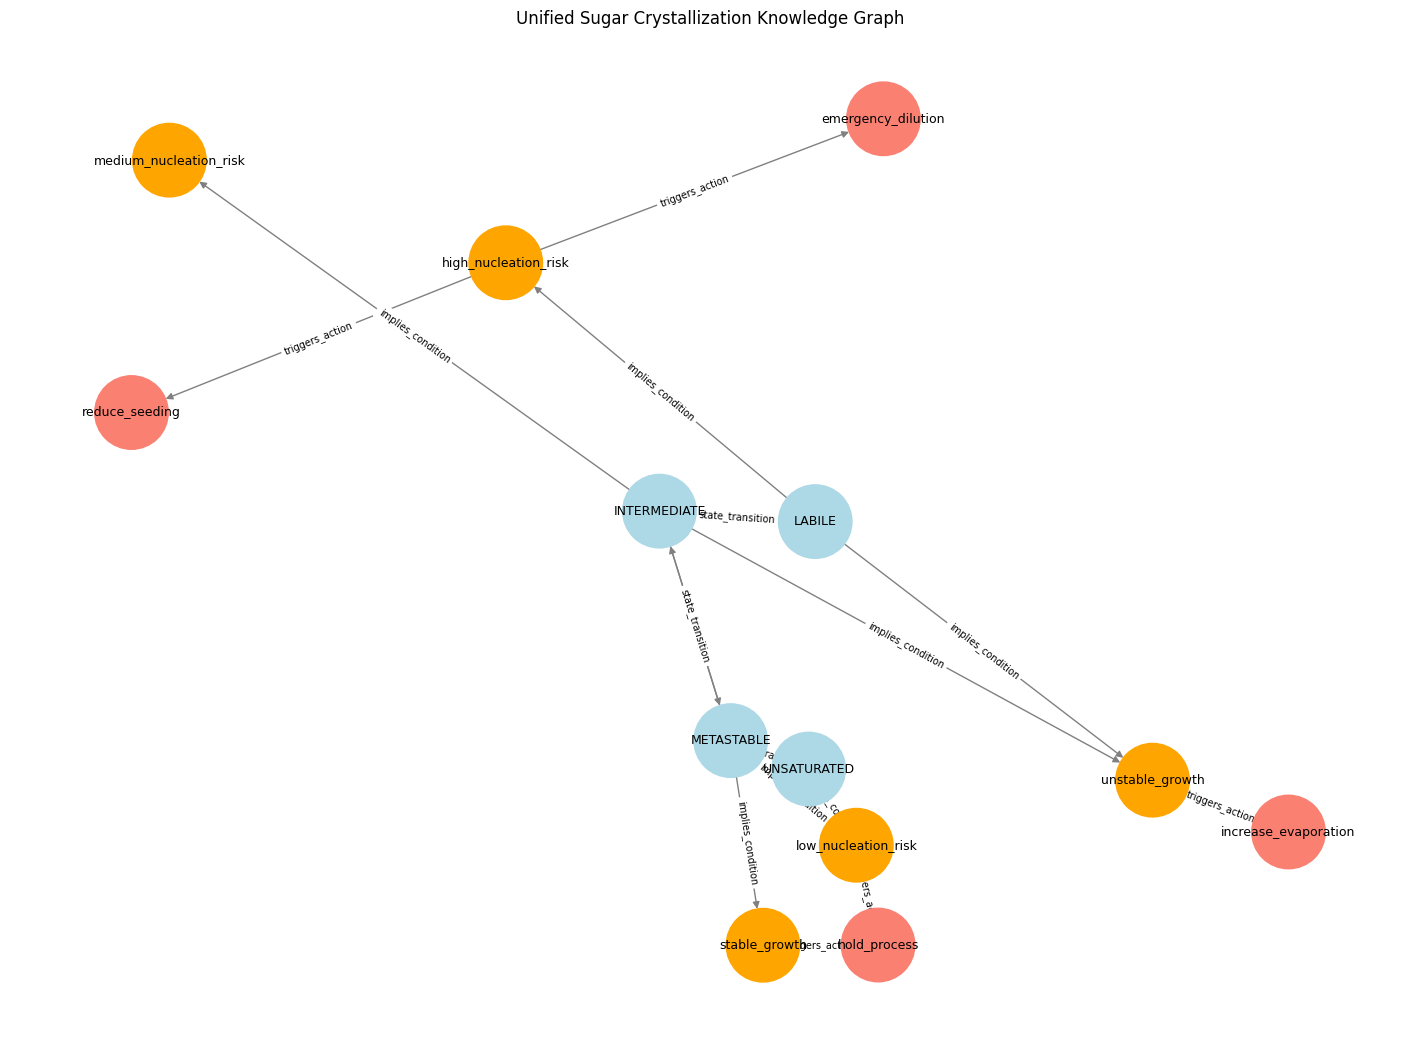

In [126]:
color_map = []
for n in KG.nodes():
    t = KG.nodes[n]["node_type"]
    if t == "state":
        color_map.append("lightblue")
    elif t == "condition":
        color_map.append("orange")
    else:
        color_map.append("salmon")

plt.figure(figsize=(14, 10))
nx.draw(
    KG,
    pos,
    with_labels=True,
    node_color=color_map,
    node_size=2800,
    font_size=9,
    edge_color="gray"
)

edge_labels = {
    (u, v): d["edge_type"]
    for u, v, d in KG.edges(data=True)
}

nx.draw_networkx_edge_labels(KG, pos, edge_labels=edge_labels, font_size=7)

plt.title("Unified Sugar Crystallization Knowledge Graph")
plt.show()


### Better Layout

In [ ]:
def layered_layout(graph):
    pos = {}

    x_pos = {
        "state": 0.0,
        "condition": 1.5,
        "action": 3.0
    }

    layers = {"state": [], "condition": [], "action": []}
    for n, d in graph.nodes(data=True):
        layers[d["node_type"]].append(n)

    for layer, nodes in layers.items():
        y_spacing = 1.0
        start_y = -(len(nodes) - 1) / 2

        for i, node in enumerate(sorted(nodes)):
            pos[node] = (x_pos[layer], start_y + i * y_spacing)

    return pos

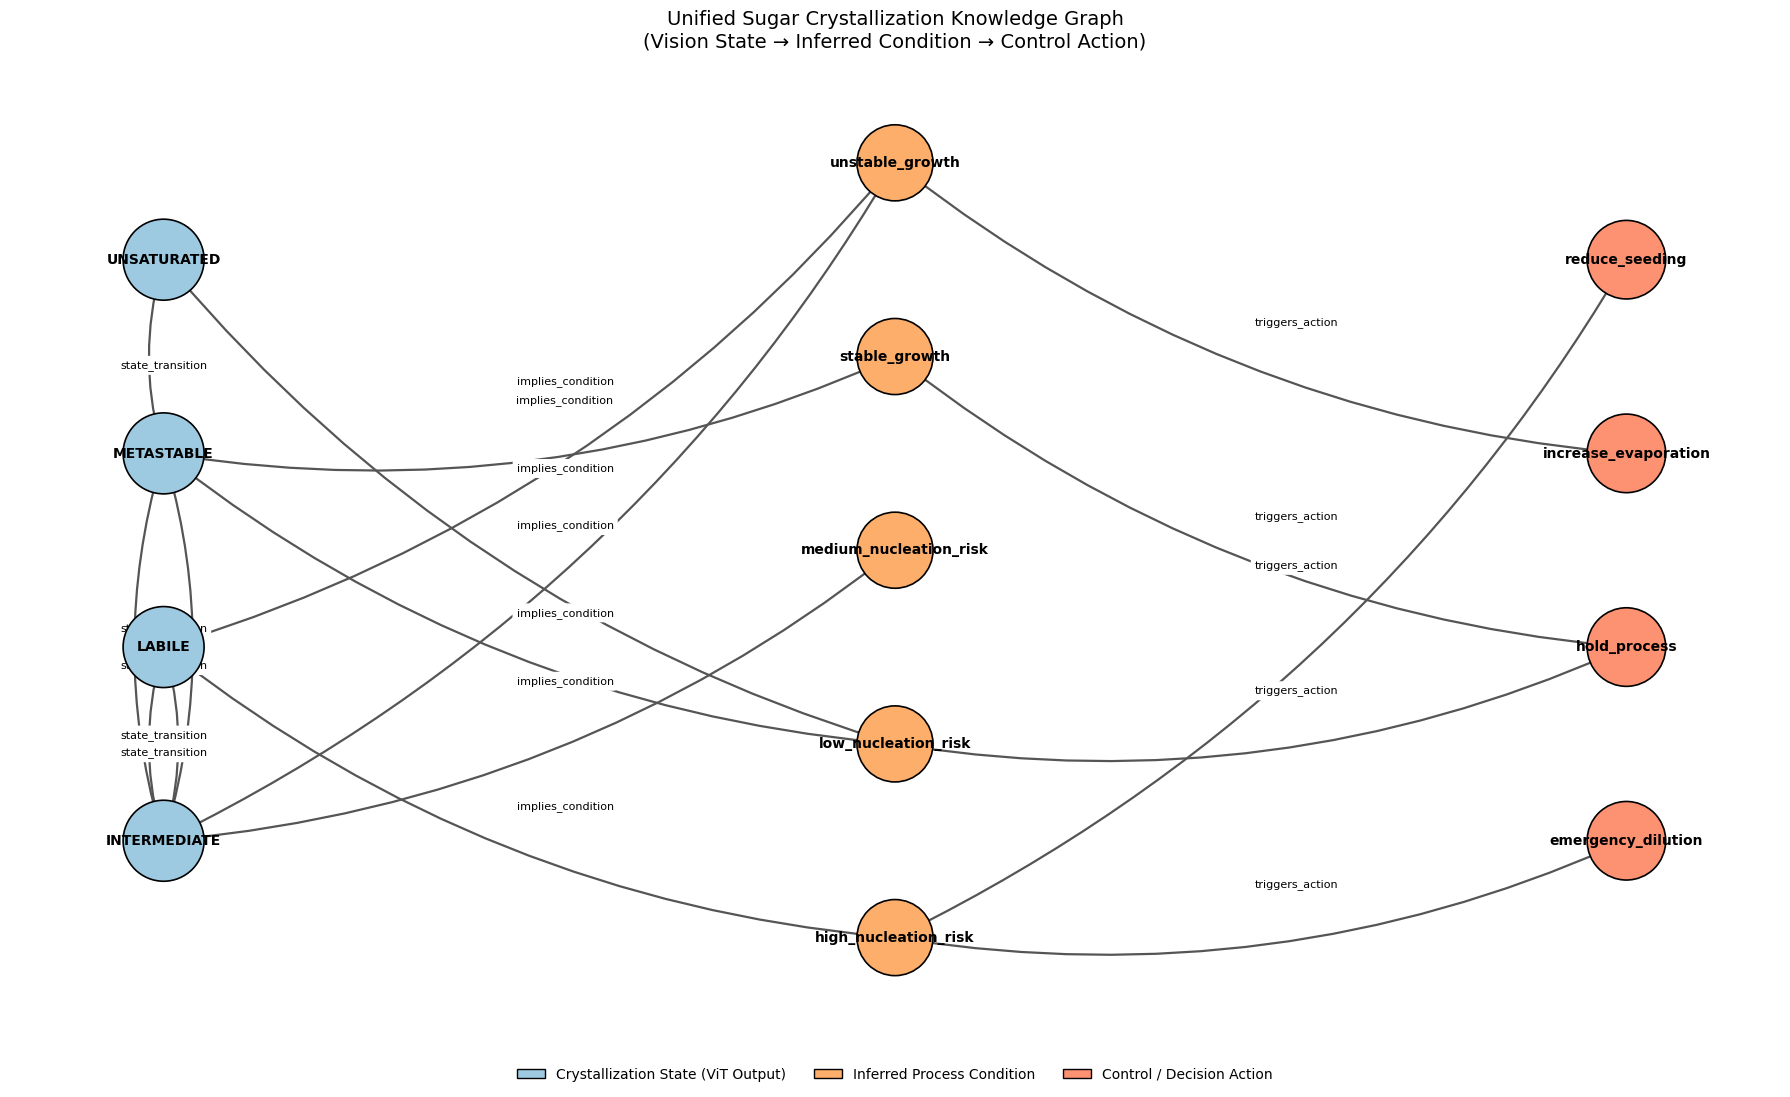

In [138]:
pos = layered_layout(KG)

plt.figure(figsize=(18, 11))

node_colors = []
node_sizes = []

for n in KG.nodes():
    t = KG.nodes[n]["node_type"]
    if t == "state":
        node_colors.append("#9ecae1") 
        node_sizes.append(3400)
    elif t == "condition":
        node_colors.append("#fdae6b")
        node_sizes.append(3000)
    else:
        node_colors.append("#fc9272")
        node_sizes.append(3200)

nx.draw_networkx_nodes(
    KG,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="black",
    linewidths=1.2
)

nx.draw_networkx_edges(
    KG,
    pos,
    arrowstyle="->",
    arrowsize=18,
    edge_color="#555555",
    width=1.6,
    connectionstyle="arc3,rad=0.15"
)

nx.draw_networkx_labels(
    KG,
    pos,
    font_size=10,
    font_weight="bold"
)

edge_labels = {
    (u, v): d["edge_type"]
    for u, v, d in KG.edges(data=True)
}

nx.draw_networkx_edge_labels(
    KG,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    label_pos=0.55,
    rotate=False
)

plt.title(
    "Unified Sugar Crystallization Knowledge Graph\n"
    "(Vision State → Inferred Condition → Control Action)",
    fontsize=14,
    pad=25
)


legend_elements = [
    Patch(facecolor="#9ecae1", edgecolor="black",
          label="Crystallization State (ViT Output)"),
    Patch(facecolor="#fdae6b", edgecolor="black",
          label="Inferred Process Condition"),
    Patch(facecolor="#fc9272", edgecolor="black",
          label="Control / Decision Action")
]

plt.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False,
    fontsize=10
)

plt.axis("off")
plt.tight_layout()
plt.show()